In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms
 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
 
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}  [{torch.cuda.get_device_name(0) if device.type=='cuda' else 'cpu'}]")

device : cuda  [Tesla T4]


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp4_equivariant_vae"
LATENT_DIM = 16        # number of latent dimensions
EPOCHS     = 50        # training epochs
BATCH_SIZE = 256       # comfortably fits P100 VRAM
LR         = 1e-3      # adam learning rate
SNAP_EVERY = 5         # show reconstruction snapshot every N epochs
GAMMA      = 100.0
C_MAX      = 25.0
C_STOP_ITER = 25000
LAMBDA_INV  = 10.0  # orbit consistency weight
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp4_equivariant_vae


In [3]:
def load_h5(path):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
ANGLES = sorted(train_angs.unique().tolist())
DIGITS = sorted(train_lbls.unique().tolist())
pin    = device.type == "cuda"
 
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs,  test_lbls,  test_angs),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)
 
print(f"train : {len(train_imgs):,}   test : {len(test_imgs):,}")
print(f"digits: {DIGITS}   angles: {ANGLES}")
 

  loading rotated_mnist_train.h5 ... done  (478 MB, 1.9s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.3s)
train : 152,400   test : 26,004
digits: [1, 2]   angles: [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]


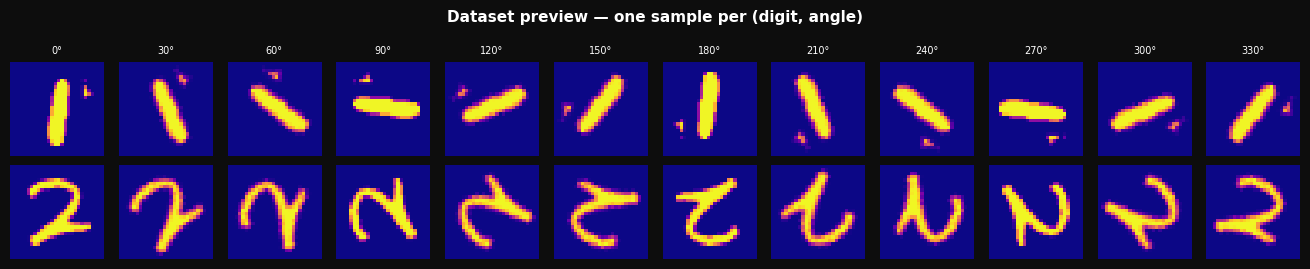

In [4]:
fig, axes = plt.subplots(len(DIGITS), len(ANGLES),
                         figsize=(len(ANGLES)*1.1, len(DIGITS)*1.4),
                         facecolor="#0d0d0d")
fig.suptitle("Dataset preview — one sample per (digit, angle)",
             color="white", fontsize=11, fontweight="bold")
 
for row, digit in enumerate(DIGITS):
    mask    = (train_lbls == digit) & (train_angs == 0)
    base    = train_imgs[mask.nonzero(as_tuple=True)[0][0]]
    for col, angle in enumerate(ANGLES):
        img = (base.squeeze().numpy() if angle == 0 else
               tvrotate(base.unsqueeze(0), float(angle),
                        interpolation=transforms.InterpolationMode.BILINEAR,
                        fill=[0.]).squeeze().numpy())
        ax = axes[row, col]
        ax.imshow(img, cmap="plasma", vmin=0, vmax=1)
        ax.axis("off")
        if row == 0: ax.set_title(f"{angle}°", color="white", fontsize=7)
        if col == 0: ax.set_ylabel(f"dig {digit}", color="white", fontsize=9, rotation=90, labelpad=5)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "00_data_preview.png"),
            dpi=120, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [5]:
class ResBlock(nn.Module):
    """residual block with groupnorm + SiLU activation"""
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.GroupNorm(g,ch), nn.SiLU(),
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.GroupNorm(g,ch),
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))   # skip connection
 
 
class Encoder(nn.Module):
    """(B,1,28,28) → μ, log σ² ∈ ℝ^latent_dim"""
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.stem  = nn.Sequential(nn.Conv2d(1,32,4,2,1,bias=False),  nn.GroupNorm(8,32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,64,4,2,1,bias=False),  nn.GroupNorm(8,64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64,128,3,2,1,bias=False), nn.GroupNorm(8,128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_lv = nn.Linear(512, latent_dim)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):   nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        return self.fc_mu(self.fc(h)), self.fc_lv(self.fc(h))
 
 
class Decoder(nn.Module):
    """z ∈ ℝ^latent_dim → (B,1,28,28)"""
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim,512), nn.SiLU(), nn.Linear(512,128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128,64,3,2,1,output_padding=1), nn.GroupNorm(8,64), nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,32,4,2,1), nn.GroupNorm(8,32), nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,1,4,2,3), nn.Sigmoid())
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d,nn.ConvTranspose2d)): nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, z):
        return self.u3(self.u2(self.u1(self.fc(z).view(-1,128,4,4))))
 
n_enc = sum(p.numel() for p in Encoder(LATENT_DIM).parameters())
n_dec = sum(p.numel() for p in Decoder(LATENT_DIM).parameters())
print(f"encoder: {n_enc:,}  decoder: {n_dec:,}  total: {n_enc+n_dec:,} params")

encoder: 1,560,928  decoder: 1,554,593  total: 3,115,521 params


In [6]:
_NONTRIVIAL = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
 
def random_rotate_batch(imgs):
    """apply a different random rotation to each image in the batch (on CPU)"""
    angles  = np.random.choice(_NONTRIVIAL, size=imgs.size(0), replace=True)
    rotated = imgs.cpu().clone()
    for b, angle in enumerate(angles):
        rotated[b:b+1] = tvrotate(
            imgs[b:b+1].cpu(), float(angle),
            interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.]
        )
    return rotated.to(imgs.device)

In [7]:
class VAE(nn.Module):
    """
    SO(2)-Invariant VAE.
    Loss = BCE + γ·|KL − C(t)|  +  λ_inv · ||z(x) − z(R_θx)||²
                                     ↑ this term teaches rotation invariance
    """
    def __init__(self, latent_dim, gamma, c_max, c_stop_iter, lambda_inv):
        super().__init__()
        self.gamma       = gamma
        self.c_max       = c_max
        self.c_stop_iter = c_stop_iter
        self.lambda_inv  = lambda_inv
        self.encoder     = Encoder(latent_dim)
        self.decoder     = Decoder(latent_dim)
 
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5*lv).exp() if self.training else mu
 
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu,lv)), mu, lv, mu
 
    def loss(self, x, x_hat, mu, lv, step=0, x_rot=None):
        N     = x.size(0)
        recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / N
        kl    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / N
        C     = float(min(self.c_max, self.c_max * step / max(self.c_stop_iter, 1)))
        cap   = self.gamma * (kl - torch.tensor(C, device=x.device)).abs()
 
        # orbit consistency: penalise distance between z(x) and z(R_θx)
        equiv = torch.tensor(0., device=x.device)
        if x_rot is not None and self.lambda_inv > 0:
            mu_rot, _ = self.encoder(x_rot)
            equiv      = F.mse_loss(mu, mu_rot)
 
        return recon + cap + self.lambda_inv * equiv, recon, kl, C, equiv.item()
 
 
model = VAE(LATENT_DIM, GAMMA, C_MAX, C_STOP_ITER, LAMBDA_INV).to(device)
print(f"SO(2)-Invariant VAE  λ_inv={LAMBDA_INV}  |  params: {sum(p.numel() for p in model.parameters()):,}")
print(f"loss = recon + {GAMMA}·|KL−C(t)| + {LAMBDA_INV}·||z(x)−z(R_θx)||²")
EXP_NAME = f"Exp4 SO(2)-Invariant VAE (λ={LAMBDA_INV})"

SO(2)-Invariant VAE  λ_inv=10.0  |  params: 3,115,521
loss = recon + 100.0·|KL−C(t)| + 10.0·||z(x)−z(R_θx)||²


In [8]:
def show_snapshot(model, epoch, n=8):
    model.eval()
    rng_idx = torch.randperm(len(test_imgs))[:n]
    imgs    = test_imgs[rng_idx].to(device)
    with torch.no_grad():
        recon = model(imgs)[0].cpu()
    fig, axes = plt.subplots(2, n, figsize=(n*1.3, 3), facecolor="#0d0d0d")
    fig.suptitle(f"Epoch {epoch}  —  top: original  |  bottom: reconstruction",
                 color="white", fontsize=9)
    for c in range(n):
        for r, dat in enumerate([imgs[c].cpu().squeeze(), recon[c].squeeze()]):
            ax = axes[r, c]
            ax.imshow(dat.numpy(), cmap="plasma", vmin=0, vmax=1)
            ax.axis("off")
            if r == 0:
                ax.set_title(f"d{test_lbls[rng_idx[c]].item()} {test_angs[rng_idx[c]].item()}°",
                             color="white", fontsize=6)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"snap_ep{epoch:03d}.png"),
                dpi=100, bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()
    model.train()

ep   1/50  │  recon  202.50  kl  0.52  C 0.30  equiv 0.04563  loss   228.05  │  val_recon  180.06  val_elbo  180.70  ← best


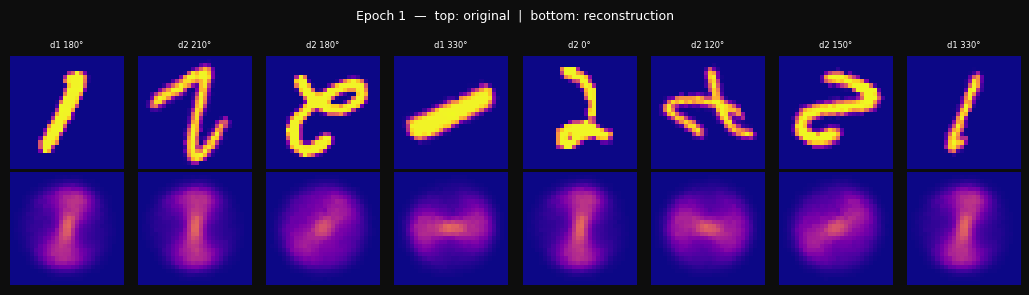

ep   2/50  │  recon  181.34  kl  0.89  C 0.89  equiv 0.12405  loss   186.64  │  val_recon  159.58  val_elbo  160.84  ← best
ep   3/50  │  recon  165.52  kl  1.49  C 1.49  equiv 0.17144  loss   169.90  │  val_recon  144.45  val_elbo  146.31  ← best
ep   4/50  │  recon  155.12  kl  2.08  C 2.09  equiv 0.18810  loss   159.69  │  val_recon  140.93  val_elbo  143.30  ← best
ep   5/50  │  recon  148.02  kl  2.68  C 2.68  equiv 0.18783  loss   152.60  │  val_recon  139.19  val_elbo  142.18  ← best


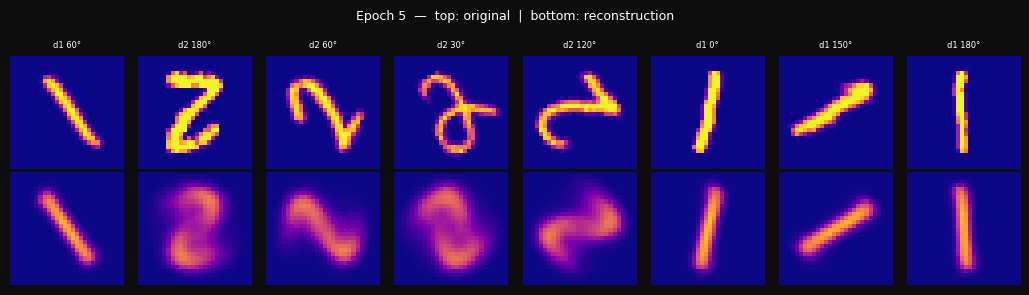

ep   6/50  │  recon  142.95  kl  3.28  C 3.28  equiv 0.17084  loss   147.59  │  val_recon  133.23  val_elbo  136.73  ← best
ep   7/50  │  recon  136.53  kl  3.87  C 3.87  equiv 0.17268  loss   140.83  │  val_recon  127.36  val_elbo  131.50  ← best
ep   8/50  │  recon  130.52  kl  4.47  C 4.47  equiv 0.17844  loss   134.38  │  val_recon  124.08  val_elbo  128.86  ← best
ep   9/50  │  recon  126.73  kl  5.06  C 5.07  equiv 0.16876  loss   130.60  │  val_recon  121.60  val_elbo  126.98  ← best
ep  10/50  │  recon  124.10  kl  5.66  C 5.66  equiv 0.16294  loss   128.39  │  val_recon  119.87  val_elbo  125.84  ← best


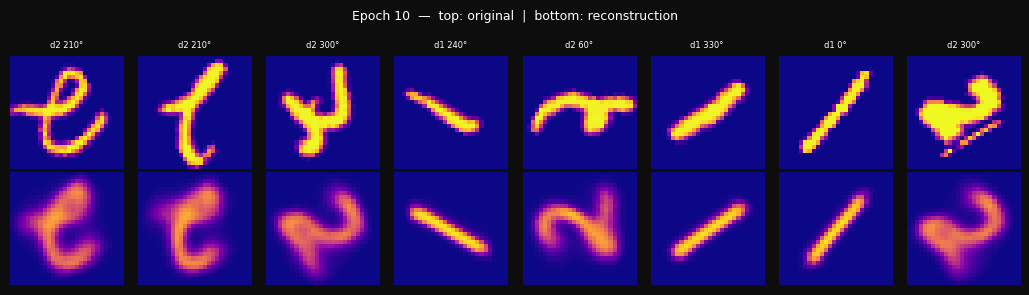

ep  11/50  │  recon  121.85  kl  6.26  C 6.26  equiv 0.14807  loss   125.53  │  val_recon  119.92  val_elbo  126.48
ep  12/50  │  recon  120.03  kl  6.85  C 6.85  equiv 0.13450  loss   123.14  │  val_recon  118.27  val_elbo  125.39  ← best
ep  13/50  │  recon  118.93  kl  7.45  C 7.45  equiv 0.12556  loss   122.74  │  val_recon  116.73  val_elbo  124.47  ← best
ep  14/50  │  recon  117.68  kl  8.05  C 8.05  equiv 0.11479  loss   121.27  │  val_recon  116.09  val_elbo  124.49  ← best
ep  15/50  │  recon  116.77  kl  8.64  C 8.64  equiv 0.10527  loss   119.33  │  val_recon  115.63  val_elbo  124.55  ← best


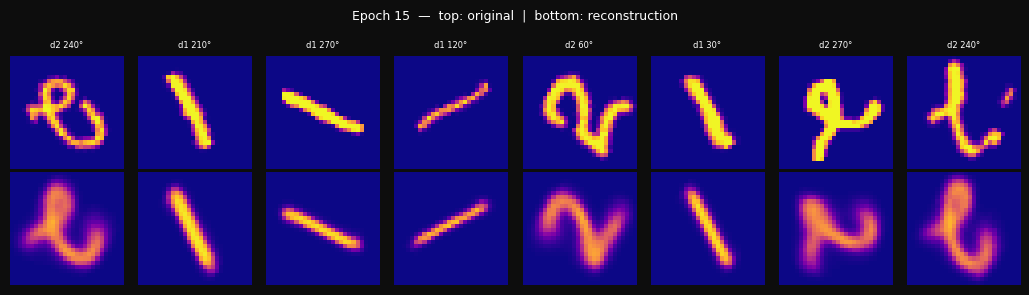

ep  16/50  │  recon  116.17  kl  9.24  C 9.24  equiv 0.10034  loss   119.04  │  val_recon  114.71  val_elbo  124.32  ← best
ep  17/50  │  recon  115.78  kl  9.83  C 9.83  equiv 0.09795  loss   119.32  │  val_recon  116.15  val_elbo  126.30
ep  18/50  │  recon  115.05  kl 10.43  C 10.43  equiv 0.08904  loss   117.57  │  val_recon  113.66  val_elbo  124.36  ← best
ep  19/50  │  recon  114.51  kl 11.03  C 11.03  equiv 0.08706  loss   117.25  │  val_recon  113.47  val_elbo  124.78  ← best
ep  20/50  │  recon  114.36  kl 11.62  C 11.62  equiv 0.08552  loss   117.18  │  val_recon  113.95  val_elbo  125.87


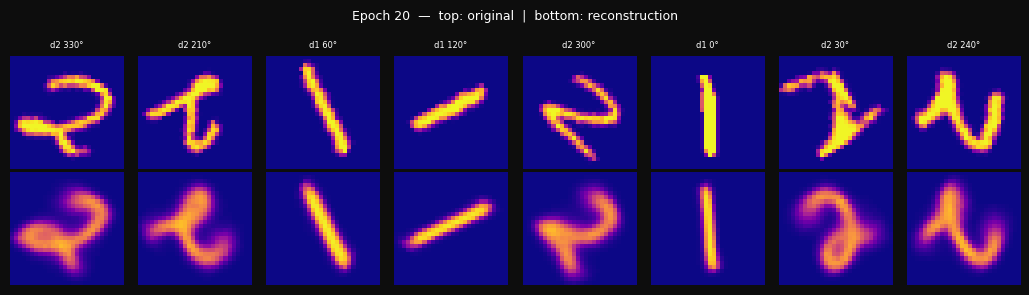

ep  21/50  │  recon  114.12  kl 12.22  C 12.22  equiv 0.08453  loss   118.24  │  val_recon  114.68  val_elbo  127.18
ep  22/50  │  recon  113.43  kl 12.82  C 12.81  equiv 0.08235  loss   116.59  │  val_recon  112.62  val_elbo  125.72  ← best
ep  23/50  │  recon  113.48  kl 13.41  C 13.41  equiv 0.08122  loss   117.02  │  val_recon  112.68  val_elbo  126.43
ep  24/50  │  recon  111.63  kl 14.01  C 14.01  equiv 0.07997  loss   113.78  │  val_recon  110.76  val_elbo  125.05  ← best
ep  25/50  │  recon  111.25  kl 14.60  C 14.60  equiv 0.07377  loss   113.51  │  val_recon  110.93  val_elbo  125.84


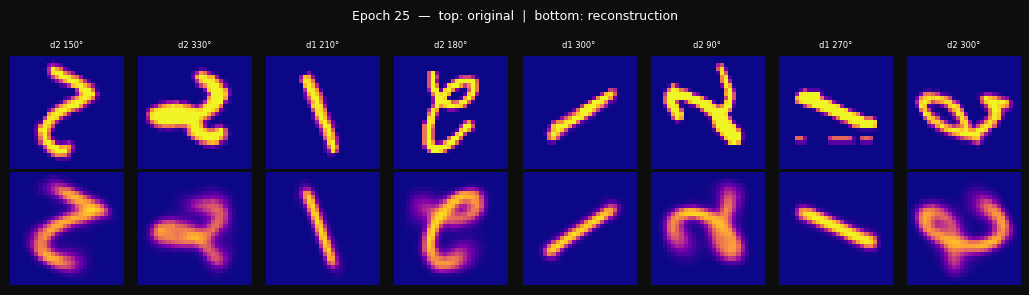

ep  26/50  │  recon  110.97  kl 15.20  C 15.20  equiv 0.07127  loss   113.38  │  val_recon  111.13  val_elbo  126.63
ep  27/50  │  recon  110.80  kl 15.79  C 15.79  equiv 0.07147  loss   112.95  │  val_recon  110.60  val_elbo  126.69  ← best
ep  28/50  │  recon  110.49  kl 16.39  C 16.39  equiv 0.07238  loss   113.02  │  val_recon  109.99  val_elbo  126.69  ← best
ep  29/50  │  recon  110.36  kl 16.99  C 16.99  equiv 0.07175  loss   112.74  │  val_recon  110.85  val_elbo  128.14
ep  30/50  │  recon  110.25  kl 17.58  C 17.58  equiv 0.07272  loss   112.66  │  val_recon  110.83  val_elbo  128.73


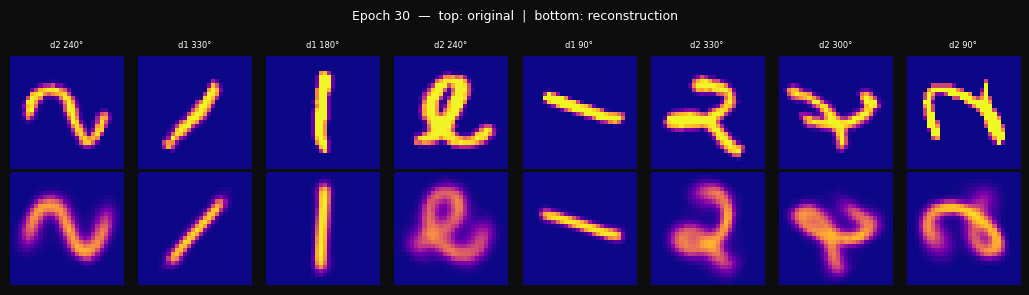

ep  31/50  │  recon  109.19  kl 18.18  C 18.18  equiv 0.07302  loss   111.33  │  val_recon  109.54  val_elbo  128.01  ← best
ep  32/50  │  recon  108.83  kl 18.77  C 18.77  equiv 0.07031  loss   110.86  │  val_recon  109.50  val_elbo  128.59  ← best
ep  33/50  │  recon  108.70  kl 19.37  C 19.37  equiv 0.07065  loss   111.16  │  val_recon  109.46  val_elbo  129.15  ← best
ep  34/50  │  recon  108.64  kl 19.97  C 19.97  equiv 0.07031  loss   111.12  │  val_recon  109.18  val_elbo  129.49  ← best
ep  35/50  │  recon  108.46  kl 20.56  C 20.56  equiv 0.07033  loss   110.87  │  val_recon  108.98  val_elbo  129.88  ← best


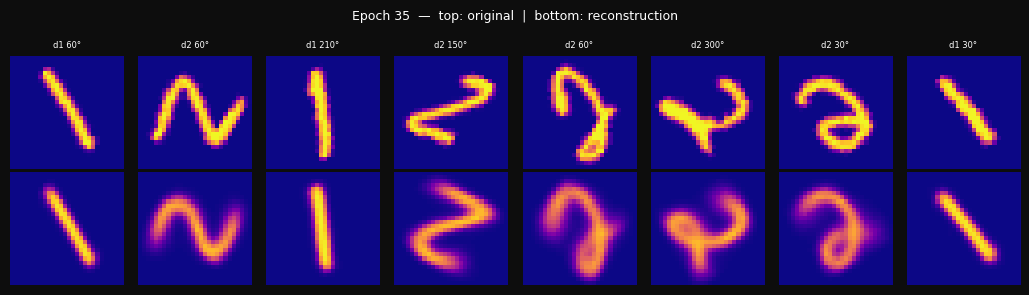

ep  36/50  │  recon  108.41  kl 21.16  C 21.16  equiv 0.06995  loss   110.95  │  val_recon  109.69  val_elbo  131.14
ep  37/50  │  recon  108.24  kl 21.75  C 21.75  equiv 0.06985  loss   111.11  │  val_recon  109.46  val_elbo  131.48
ep  38/50  │  recon  107.54  kl 22.35  C 22.35  equiv 0.06925  loss   109.71  │  val_recon  108.79  val_elbo  131.45  ← best
ep  39/50  │  recon  107.36  kl 22.95  C 22.95  equiv 0.06880  loss   109.55  │  val_recon  108.72  val_elbo  131.97  ← best
ep  40/50  │  recon  107.36  kl 23.54  C 23.54  equiv 0.06856  loss   109.56  │  val_recon  108.55  val_elbo  132.39  ← best


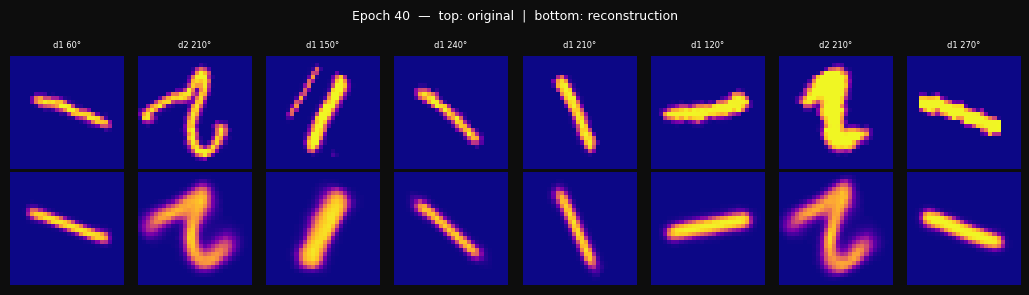

ep  41/50  │  recon  107.25  kl 24.14  C 24.14  equiv 0.06887  loss   109.57  │  val_recon  109.02  val_elbo  133.46
ep  42/50  │  recon  107.17  kl 24.73  C 24.73  equiv 0.06900  loss   109.74  │  val_recon  108.66  val_elbo  133.64
ep  43/50  │  recon  107.08  kl 25.00  C 25.00  equiv 0.06834  loss   109.58  │  val_recon  108.67  val_elbo  133.66
ep  44/50  │  recon  107.05  kl 25.00  C 25.00  equiv 0.06689  loss   109.44  │  val_recon  108.60  val_elbo  133.63
ep  45/50  │  recon  106.61  kl 25.00  C 25.00  equiv 0.06519  loss   108.70  │  val_recon  108.72  val_elbo  133.74


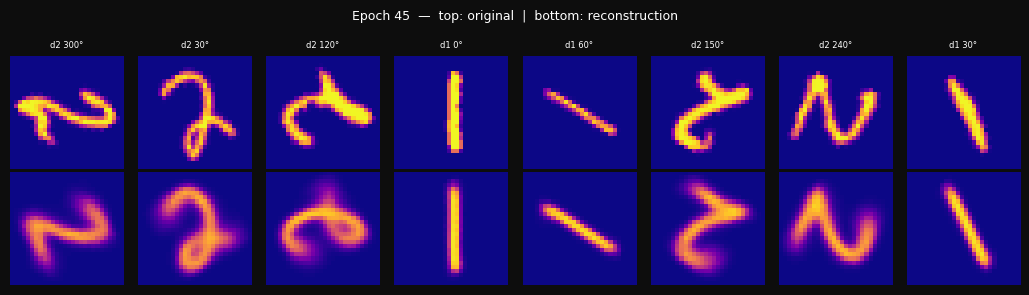

ep  46/50  │  recon  106.47  kl 25.00  C 25.00  equiv 0.06336  loss   108.24  │  val_recon  108.32  val_elbo  133.33  ← best
ep  47/50  │  recon  106.37  kl 25.00  C 25.00  equiv 0.06227  loss   108.05  │  val_recon  108.30  val_elbo  133.30  ← best
ep  48/50  │  recon  106.35  kl 25.00  C 25.00  equiv 0.06042  loss   108.06  │  val_recon  108.35  val_elbo  133.37
ep  49/50  │  recon  106.27  kl 25.00  C 25.00  equiv 0.05974  loss   107.86  │  val_recon  108.31  val_elbo  133.30
ep  50/50  │  recon  106.26  kl 25.00  C 25.00  equiv 0.05864  loss   107.91  │  val_recon  108.33  val_elbo  133.35


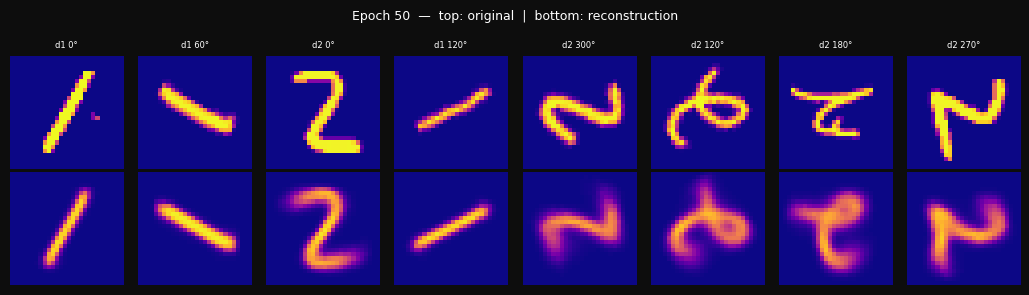


best model loaded  (epoch 47, val_elbo=108.30)


In [9]:
opt       = torch.optim.Adam(model.parameters(), lr=LR)
sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=6)
history   = {k:[] for k in ["train_loss","train_recon","train_kl","train_C","train_equiv",
                             "val_loss",  "val_recon",  "val_kl",  "val_elbo"]}
snapshots = {}
best_val  = float("inf")
step      = 0
 
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
 
    model.train()
    tr = {"loss":0., "recon":0., "kl":0., "C":0., "equiv":0.}
    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True); opt.zero_grad()
        x_hat, mu, lv, _ = model(imgs)
        # generate orbit pair — no gradient through the rotation
        with torch.no_grad():
            imgs_rot = random_rotate_batch(imgs)
        total, recon, kl, C, eq = model.loss(imgs, x_hat, mu, lv, step=step, x_rot=imgs_rot)
        total.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.); opt.step()
        step += 1
        tr["loss"]+=total.item(); tr["recon"]+=recon.item()
        tr["kl"]+=kl.item(); tr["C"]+=C; tr["equiv"]+=eq
    tr = {k: v/len(train_loader) for k,v in tr.items()}
 
    model.eval()
    va = {"loss":0., "recon":0., "kl":0., "elbo":0.}
    with torch.no_grad():
        for imgs, _, _ in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            x_hat, mu, lv, _ = model(imgs)
            total, recon, kl, _, _ = model.loss(imgs, x_hat, mu, lv, step=step)
            va["loss"]+=total.item(); va["recon"]+=recon.item(); va["kl"]+=kl.item()
            va["elbo"]+=(recon + kl).item()
    va = {k: v/len(test_loader) for k,v in va.items()}
 
    sched.step(va["elbo"])
    for k in tr: history[f"train_{k}"].append(tr[k])
    for k in va: history[f"val_{k}"].append(va[k])
 
    if va["recon"] < best_val:  # track on val_recon, not val_elbo (KL grows with C)
        best_val = va["recon"]  # save val_recon as the criterion
        torch.save({"model": model.state_dict(),
                    "cfg": {"latent_dim": LATENT_DIM, "gamma": GAMMA,
                            "c_max": C_MAX, "c_stop_iter": C_STOP_ITER,
                            "lambda_inv": LAMBDA_INV},
                    "epoch": epoch, "val_elbo": best_val},
                   os.path.join(OUT_DIR, "best_model.pt"))
 
    print(f"ep {epoch:3d}/{EPOCHS}  │  "
          f"recon {tr['recon']:7.2f}  kl {tr['kl']:5.2f}  "
          f"C {tr['C']:.2f}  equiv {tr['equiv']:.5f}  loss {tr['loss']:8.2f}  │  "
          f"val_recon {va['recon']:7.2f}  val_elbo {va['elbo']:7.2f}"
          + ("  ← best" if va["recon"] == best_val else ""))
 
    if epoch % SNAP_EVERY == 0 or epoch == 1:
        show_snapshot(model, epoch)
        model.eval()
        rng_idx = torch.randperm(len(test_imgs))[:8]
        with torch.no_grad():
            si = test_imgs[rng_idx].to(device)
            sr = model(si)[0].cpu()
        snapshots[epoch] = (test_imgs[rng_idx].squeeze(1).numpy(), sr.squeeze(1).numpy())
        model.train()
 
ckpt = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
best_model = VAE(LATENT_DIM, GAMMA, C_MAX, C_STOP_ITER, LAMBDA_INV).to(device)
best_model.load_state_dict(ckpt["model"]); best_model.eval()
print(f"\nbest model loaded  (epoch {ckpt['epoch']}, val_elbo={ckpt['val_elbo']:.2f})")

In [10]:
@torch.no_grad()
def encode_all(model):
    model.eval()
    Zs, Ls, As = [], [], []
    for imgs, lbls, angs in tqdm(test_loader, desc="encoding", leave=False):
        mu, _ = model.encoder(imgs.to(device, non_blocking=True))
        Zs.append(mu.cpu().numpy())
        Ls.append(lbls.numpy())
        As.append(angs.numpy())
    return np.concatenate(Zs), np.concatenate(Ls), np.concatenate(As)
 
Z, Ls, As = encode_all(best_model)
print(f"latent codes: {Z.shape}  |  min={Z.min():.2f}  max={Z.max():.2f}  std={Z.std():.2f}")

encoding:   0%|          | 0/102 [00:00<?, ?it/s]

latent codes: (26004, 16)  |  min=-1.39  max=1.89  std=0.22


In [11]:
@torch.no_grad()
def compute_rie(model, n_samples=600):
    model.eval()
    base_pool = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()
    rng       = np.random.default_rng(42)
    bidx      = rng.choice(base_pool, min(n_samples, len(base_pool)), replace=False)
    per_angle = {}
    for angle in ANGLES:
        if angle == 0:
            per_angle[0] = 0.0
            continue
        diffs = []
        for s in range(0, len(bidx), 256):
            b      = bidx[s:s+256]
            img0   = test_imgs[b].to(device)
            img_th = tvrotate(img0, float(angle),
                              interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
            mu0, _ = model.encoder(img0)
            mu_th, _ = model.encoder(img_th)
            diffs.extend((mu0 - mu_th).norm(dim=1).cpu().numpy().tolist())
        per_angle[angle] = float(np.mean(diffs))
    rie = float(np.mean([v for v in per_angle.values() if v > 0]))
    return rie, per_angle

In [12]:
def compute_lp_auc(Z, Ls):
    n    = len(Z)
    perm = np.random.default_rng(0).permutation(n)
    sp   = int(n * 0.8)
    tr_Z, va_Z = Z[perm[:sp]], Z[perm[sp:]]
    tr_L, va_L = Ls[perm[:sp]], Ls[perm[sp:]]
    clf  = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")
    clf.fit(tr_Z, tr_L)
    prob = clf.predict_proba(va_Z)[:, 1]
    return float(roc_auc_score(va_L, prob))

In [13]:
def _fit_circle(pts):
    x, y = pts[:,0], pts[:,1]
    A = np.column_stack([x, y, np.ones(len(x))])
    b = -(x**2 + y**2)
    try:
        c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    except np.linalg.LinAlgError:
        return 0.0, 1.0
    cx, cy = -c[0]/2, -c[1]/2
    r      = max(np.sqrt(cx**2 + cy**2 - c[2]), 1e-6)
    resid  = np.mean(np.abs(np.sqrt((x-cx)**2 + (y-cy)**2) - r))
    return r, resid
 
@torch.no_grad()
def compute_ocs(model, n_orbits=50):
    model.eval()
    base_pool = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()
    bidx      = np.random.default_rng(1).choice(base_pool, min(n_orbits,len(base_pool)), replace=False)
    K   = len(ANGLES)
    lat = model.encoder.latent_dim
    all_Z = np.zeros((len(bidx), K, lat))
    for i, b in enumerate(bidx):
        base = test_imgs[b:b+1]
        for k, angle in enumerate(ANGLES):
            img = (base if angle == 0 else
                   tvrotate(base, float(angle),
                            interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.]))
            mu, _ = model.encoder(img.to(device))
            all_Z[i,k] = mu.cpu().numpy()
    pca = PCA(n_components=2)
    Z2  = pca.fit_transform(all_Z.reshape(-1,lat)).reshape(len(bidx),K,2)
    scores = []
    for i in range(len(bidx)):
        pts    = Z2[i]
        radius = np.max(np.linalg.norm(pts - pts.mean(0), axis=1))
        if radius < 1e-4:
            scores.append(0.0)   # collapsed orbit
            continue
        r, resid = _fit_circle(pts)
        scores.append(max(0.0, 1.0 - resid/radius))
    return float(np.mean(scores))

In [14]:
print("computing evaluation metrics ...")
print("(this replaces ELBO as the primary evaluation for symmetry discovery)")
print()
 
print("  metric 1: Rotation Invariance Error ...", end=" ", flush=True)
rie, rie_per_angle = compute_rie(best_model)
print(f"RIE = {rie:.4f}")
 
print("  metric 2: Linear Probe AUC ...", end=" ", flush=True)
lp_auc = compute_lp_auc(Z, Ls)
print(f"AUC = {lp_auc:.4f}")
 
print("  metric 3: Orbit Circularity Score ...", end=" ", flush=True)
ocs = compute_ocs(best_model)
print(f"OCS = {ocs:.4f}")

computing evaluation metrics ...
(this replaces ELBO as the primary evaluation for symmetry discovery)

  metric 1: Rotation Invariance Error ... RIE = 0.8597
  metric 2: Linear Probe AUC ... AUC = 0.9968
  metric 3: Orbit Circularity Score ... OCS = 0.8250


  running t-SNE ... 12s


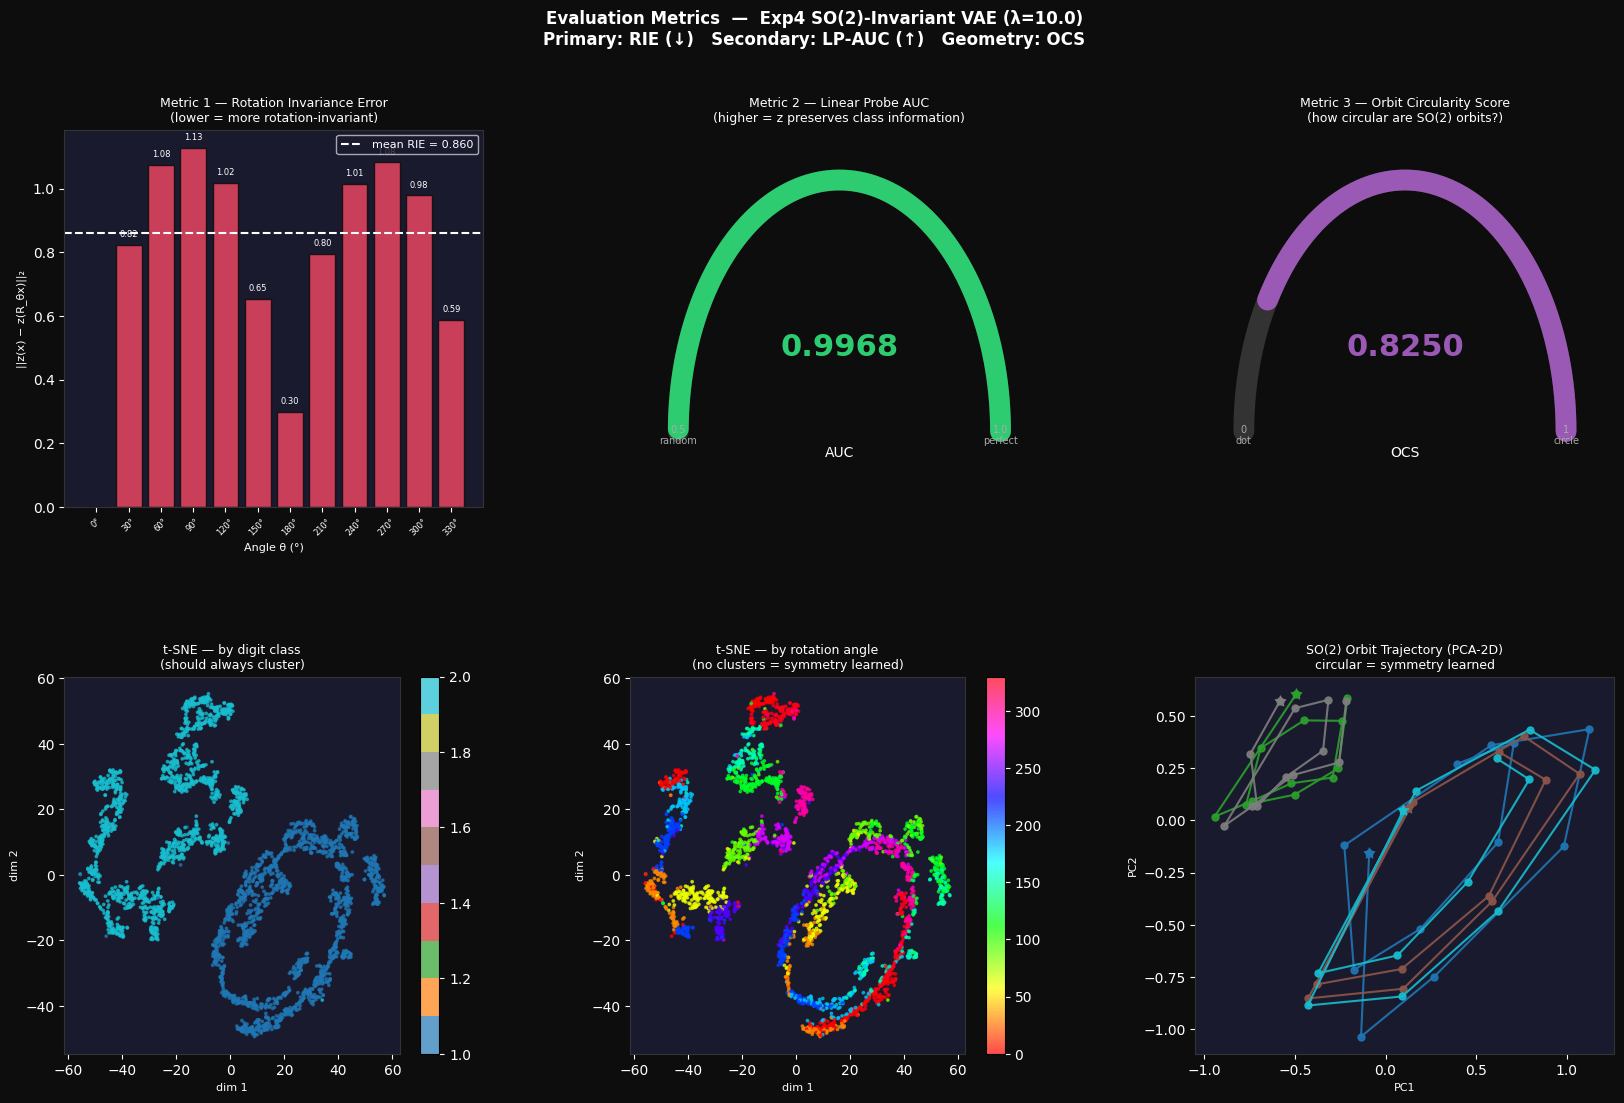

In [15]:
def _sax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#333")
    ax.set_title(title, color="white", fontsize=9)
    if xlabel: ax.set_xlabel(xlabel, color="white", fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color="white", fontsize=8)
 
fig = plt.figure(figsize=(20, 12), facecolor="#0d0d0d")
fig.suptitle(f"Evaluation Metrics  —  {EXP_NAME}\n"
             "Primary: RIE (↓)   Secondary: LP-AUC (↑)   Geometry: OCS",
             color="white", fontsize=12, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── panel 1: RIE per angle (bar) ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_sax(ax1, "Metric 1 — Rotation Invariance Error\n(lower = more rotation-invariant)",
     "Angle θ (°)", "||z(x) − z(R_θx)||₂")
ang_l = list(rie_per_angle.keys())
err_l = list(rie_per_angle.values())
bars  = ax1.bar(range(len(ang_l)), err_l, color="#e94560", alpha=0.85, edgecolor="#0d0d0d")
ax1.axhline(rie, color="white", ls="--", lw=1.5, label=f"mean RIE = {rie:.3f}")
ax1.set_xticks(range(len(ang_l)))
ax1.set_xticklabels([f"{a}°" for a in ang_l], color="white", fontsize=6, rotation=45)
ax1.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
for bar, v in zip(bars, err_l):
    if v > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, v+rie*0.03,
                 f"{v:.2f}", ha="center", color="white", fontsize=6)
 
# ── panel 2: linear probe AUC gauge ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
_sax(ax2, "Metric 2 — Linear Probe AUC\n(higher = z preserves class information)")
# draw a simple arc gauge
theta = np.linspace(0, np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), color="#333", lw=15, solid_capstyle="round")
# fill up to auc value
fill_theta = np.linspace(0, np.pi * lp_auc, 200)
color_auc  = "#2ecc71" if lp_auc > 0.9 else "#f5a623" if lp_auc > 0.75 else "#e94560"
ax2.plot(np.cos(fill_theta), np.sin(fill_theta), color=color_auc,
         lw=15, solid_capstyle="round")
ax2.text(0, 0.3, f"{lp_auc:.4f}", ha="center", color=color_auc,
         fontsize=22, fontweight="bold")
ax2.text(0, -0.1, "AUC", ha="center", color="white", fontsize=10)
ax2.text(-1.0, -0.05, "0.5\nrandom", ha="center", color="#aaa", fontsize=7)
ax2.text( 1.0, -0.05, "1.0\nperfect", ha="center", color="#aaa", fontsize=7)
ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.3, 1.2)
ax2.axis("off")
 
# ── panel 3: OCS gauge ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_sax(ax3, "Metric 3 — Orbit Circularity Score\n(how circular are SO(2) orbits?)")
ax3.plot(np.cos(theta), np.sin(theta), color="#333", lw=15, solid_capstyle="round")
fill_ocs  = np.linspace(0, np.pi * ocs, 200)
color_ocs = "#9b59b6"
ax3.plot(np.cos(fill_ocs), np.sin(fill_ocs), color=color_ocs,
         lw=15, solid_capstyle="round")
ax3.text(0, 0.3, f"{ocs:.4f}", ha="center", color=color_ocs,
         fontsize=22, fontweight="bold")
ax3.text(0, -0.1, "OCS", ha="center", color="white", fontsize=10)
ax3.text(-1.0, -0.05, "0\ndot", ha="center", color="#aaa", fontsize=7)
ax3.text( 1.0, -0.05, "1\ncircle", ha="center", color="#aaa", fontsize=7)
ax3.set_xlim(-1.3, 1.3); ax3.set_ylim(-0.3, 1.2)
ax3.axis("off")
 
# ── panel 4: t-SNE coloured by digit and angle ───────────────────────────────
MAX_PTS = 3000
rng_tsne = np.random.default_rng(0)
idx_tsne = rng_tsne.choice(len(Z), min(MAX_PTS, len(Z)), replace=False)
Z_s, L_s, A_s = Z[idx_tsne], Ls[idx_tsne], As[idx_tsne]
print("  running t-SNE ...", end=" ", flush=True)
t0 = time.time()
Z2_tsne = TSNE(n_components=2, random_state=42, perplexity=40,
               n_iter=1000, learning_rate="auto", init="pca").fit_transform(Z_s)
print(f"{time.time()-t0:.0f}s")
 
ax4 = fig.add_subplot(gs[1, 0])
_sax(ax4, "t-SNE — by digit class\n(should always cluster)", "dim 1", "dim 2")
sc = ax4.scatter(Z2_tsne[:,0], Z2_tsne[:,1], c=L_s, cmap="tab10", s=3, alpha=0.7)
plt.colorbar(sc, ax=ax4).ax.tick_params(colors="white")
 
ax5 = fig.add_subplot(gs[1, 1])
_sax(ax5, "t-SNE — by rotation angle\n(no clusters = symmetry learned)", "dim 1", "dim 2")
sc5 = ax5.scatter(Z2_tsne[:,0], Z2_tsne[:,1], c=A_s, cmap="hsv", s=3, alpha=0.7)
plt.colorbar(sc5, ax=ax5).ax.tick_params(colors="white")
 
# ── panel 5: SO(2) orbit trajectory ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
_sax(ax6, "SO(2) Orbit Trajectory (PCA-2D)\ncircular = symmetry learned", "PC1", "PC2")
 
N_ORBITS   = 5
base_pool  = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()[:N_ORBITS]
K          = len(ANGLES)
lat        = best_model.encoder.latent_dim
all_Z_orb  = np.zeros((N_ORBITS, K, lat))
orb_cols   = plt.cm.tab10(np.linspace(0,1,N_ORBITS))
with torch.no_grad():
    for i, b in enumerate(base_pool):
        base = test_imgs[b:b+1]
        for k, angle in enumerate(ANGLES):
            img = (base if angle==0 else
                   tvrotate(base, float(angle),
                            interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.]))
            mu,_ = best_model.encoder(img.to(device))
            all_Z_orb[i,k] = mu.cpu().numpy()
pca2  = PCA(n_components=2)
Z2orb = pca2.fit_transform(all_Z_orb.reshape(-1,lat)).reshape(N_ORBITS,K,2)
for i in range(N_ORBITS):
    path = Z2orb[i]
    ax6.plot(path[:,0], path[:,1], "-o", color=orb_cols[i], ms=5, lw=1.5, alpha=0.9)
    ax6.scatter(path[0,0], path[0,1], color=orb_cols[i], s=60, marker="*", zorder=5)
 
plt.savefig(os.path.join(OUT_DIR, "E_eval_metrics.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

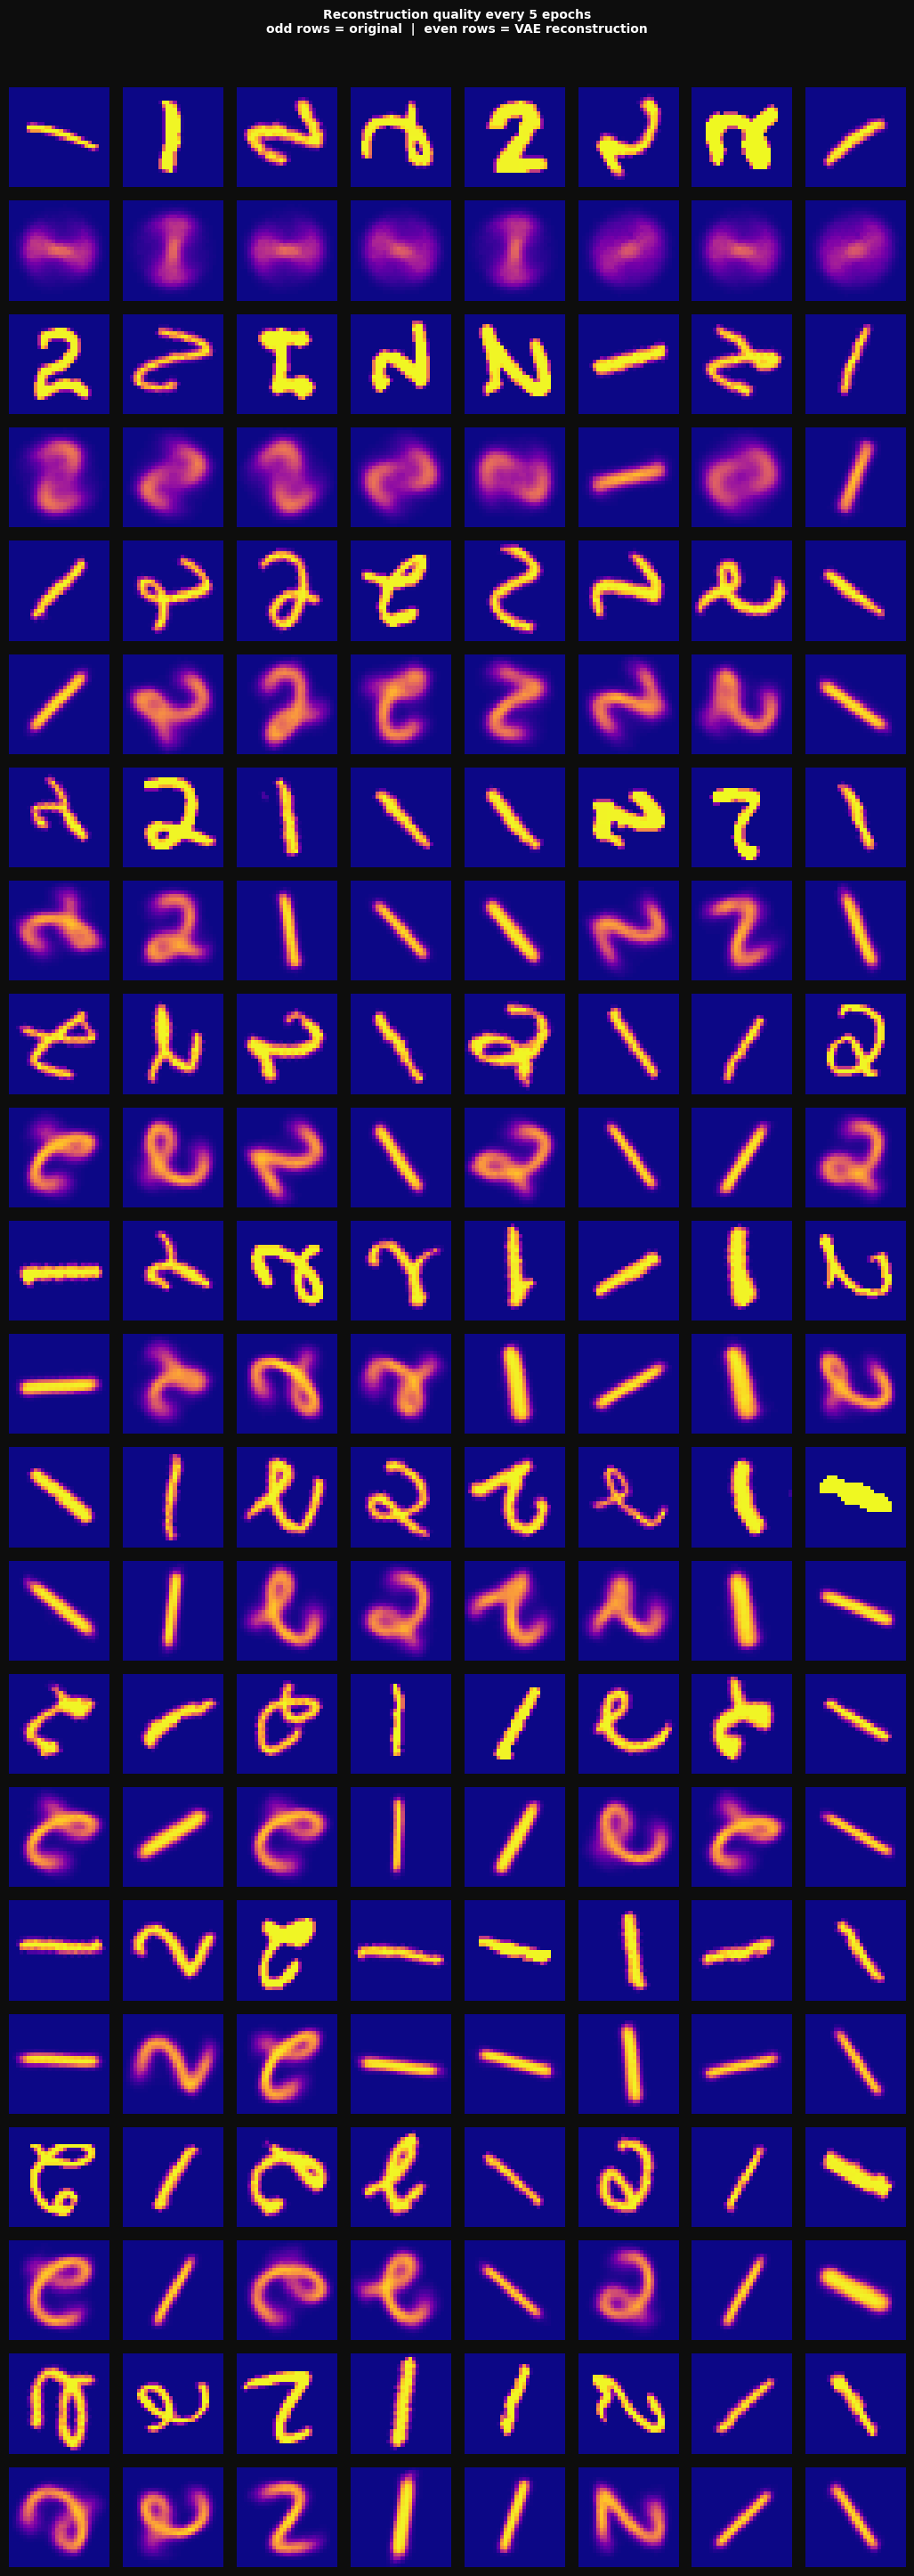

In [16]:
ep_list = sorted(snapshots.keys())
n_imgs  = 8
fig = plt.figure(figsize=(n_imgs*1.3, len(ep_list)*2.6), facecolor="#0d0d0d")
fig.suptitle("Reconstruction quality every 5 epochs\n"
             "odd rows = original  |  even rows = VAE reconstruction",
             color="white", fontsize=10, fontweight="bold", y=1.01)
 
for ri, ep in enumerate(ep_list):
    orig_np, recon_np = snapshots[ep]
    for c in range(n_imgs):
        ax = fig.add_subplot(len(ep_list)*2, n_imgs, ri*2*n_imgs + c + 1)
        ax.imshow(orig_np[c], cmap="plasma", vmin=0, vmax=1); ax.axis("off")
        if c == 0: ax.set_ylabel(f"Ep {ep}\norig", color="white", fontsize=7, rotation=0, labelpad=40)
        ax = fig.add_subplot(len(ep_list)*2, n_imgs, ri*2*n_imgs + n_imgs + c + 1)
        ax.imshow(recon_np[c], cmap="plasma", vmin=0, vmax=1); ax.axis("off")
        if c == 0: ax.set_ylabel("recon", color="#aaa", fontsize=7, rotation=0, labelpad=35)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "B_epoch_snapshots.png"),
            dpi=130, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

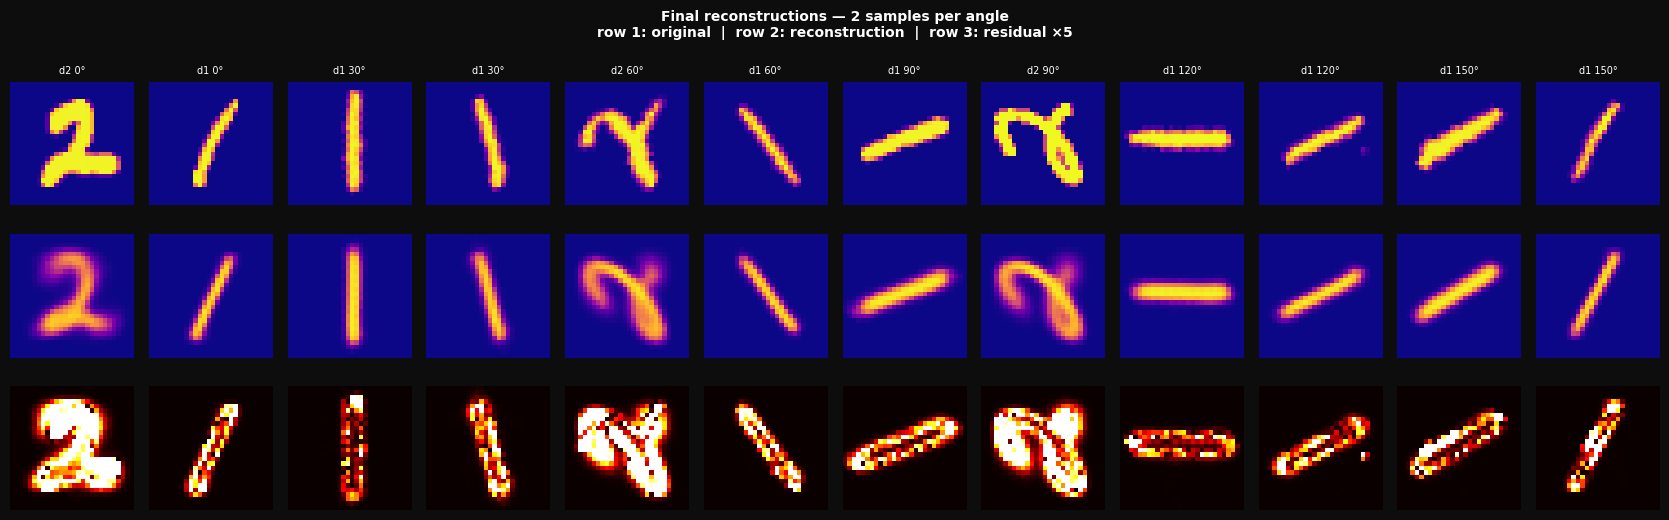

In [17]:
n = 12
best_model.eval()
rng_idx = []
for angle in ANGLES[:6]:
    mask  = (test_angs == angle).nonzero(as_tuple=True)[0]
    picks = mask[torch.randperm(len(mask))[:2]]
    rng_idx.extend(picks.tolist())
 
imgs_show = test_imgs[rng_idx].to(device)
with torch.no_grad():
    recon_show = best_model(imgs_show)[0].cpu()
 
fig, axes = plt.subplots(3, n, figsize=(n*1.4, 5.5), facecolor="#0d0d0d")
fig.suptitle("Final reconstructions — 2 samples per angle\n"
             "row 1: original  |  row 2: reconstruction  |  row 3: residual ×5",
             color="white", fontsize=10, fontweight="bold")
 
for c in range(n):
    orig  = imgs_show[c].cpu().squeeze().numpy()
    recon = recon_show[c].squeeze().numpy()
    resid = np.abs(orig - recon) * 5
    for r, (dat, cmap) in enumerate([(orig,"plasma"),(recon,"plasma"),(resid,"hot")]):
        ax = axes[r, c]
        ax.imshow(dat, cmap=cmap, vmin=0, vmax=1); ax.axis("off")
        if r == 0:
            ax.set_title(f"d{test_lbls[rng_idx[c]].item()} {test_angs[rng_idx[c]].item()}°",
                         color="white", fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "C_reconstructions.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

top-4 active dims : [3, 0, 13, 15]  (KL: [10.98900032043457, 10.758000373840332, 1.1239999532699585, 0.9750000238418579])


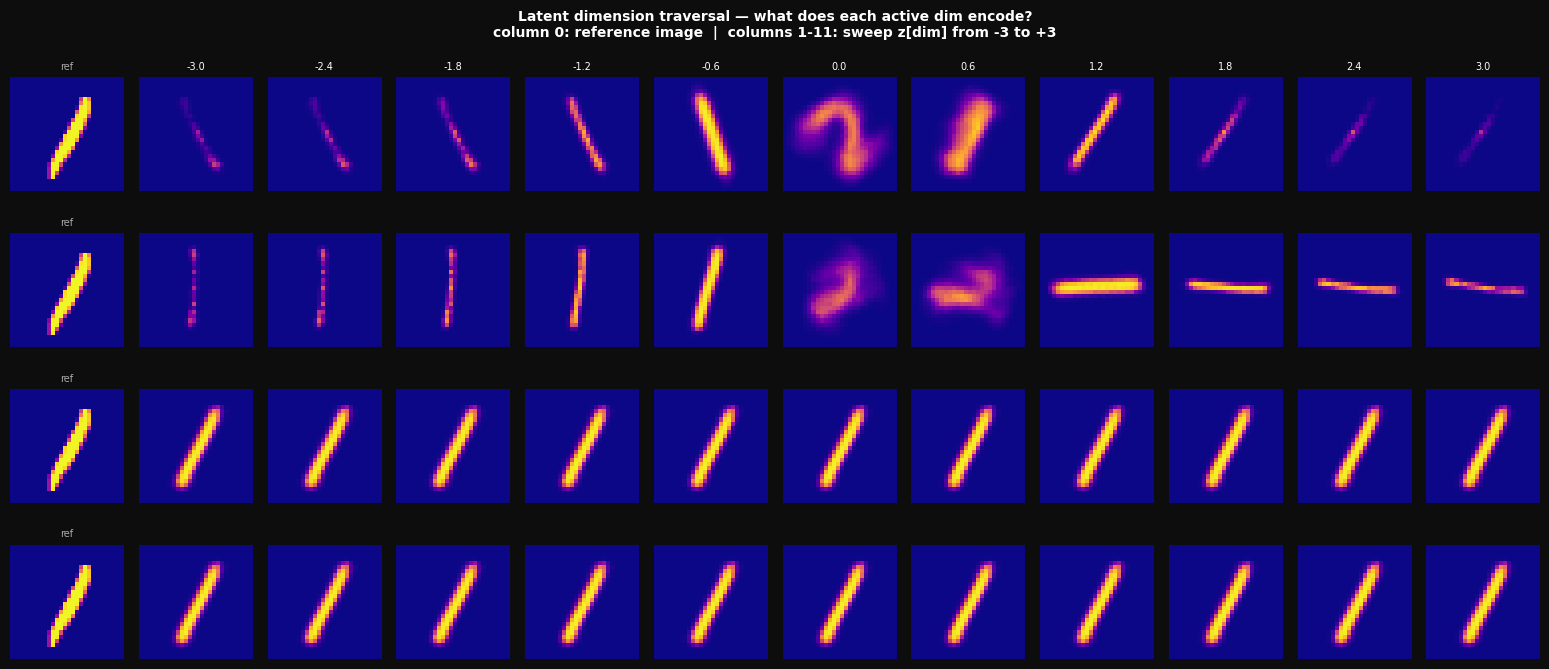

In [18]:
best_model.eval()
kl_acc = None; nb = 0
with torch.no_grad():
    for imgs, _, _ in test_loader:
        mu, lv = best_model.encoder(imgs.to(device, non_blocking=True))
        kl = -0.5 * (1 + lv - mu.pow(2) - lv.exp())
        kl_acc = kl.mean(0).cpu().numpy() if kl_acc is None else kl_acc + kl.mean(0).cpu().numpy()
        nb += 1
kl_per_dim = kl_acc / nb
top4 = kl_per_dim.argsort()[::-1][:4]
print(f"top-4 active dims : {top4.tolist()}  (KL: {kl_per_dim[top4].round(3).tolist()})")
 
# use a random test image as reference
ref_idx = torch.randperm(len(test_imgs))[0]
ref_img = test_imgs[ref_idx:ref_idx+1].to(device)
with torch.no_grad():
    ref_mu, _ = best_model.encoder(ref_img)
 
N_STEPS = 11
vals    = np.linspace(-3.0, 3.0, N_STEPS)
 
fig, axes = plt.subplots(4, N_STEPS+1, figsize=((N_STEPS+1)*1.3, 7), facecolor="#0d0d0d")
fig.suptitle("Latent dimension traversal — what does each active dim encode?\n"
             "column 0: reference image  |  columns 1-11: sweep z[dim] from -3 to +3",
             color="white", fontsize=10, fontweight="bold")
 
with torch.no_grad():
    for row, dim in enumerate(top4):
        axes[row,0].imshow(ref_img.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
        axes[row,0].axis("off")
        axes[row,0].set_title("ref", color="#aaa", fontsize=7)
        axes[row,0].set_ylabel(f"z[{int(dim)}]\nKL={kl_per_dim[dim]:.2f}",
                               color="white", fontsize=8, rotation=0, labelpad=44)
        for col, val in enumerate(vals):
            z = ref_mu.clone(); z[0, int(dim)] = val
            recon = best_model.decoder(z).cpu().squeeze().numpy()
            ax = axes[row, col+1]
            ax.imshow(recon, cmap="plasma", vmin=0, vmax=1); ax.axis("off")
            if row == 0: ax.set_title(f"{val:.1f}", color="white", fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "D_latent_traversal.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

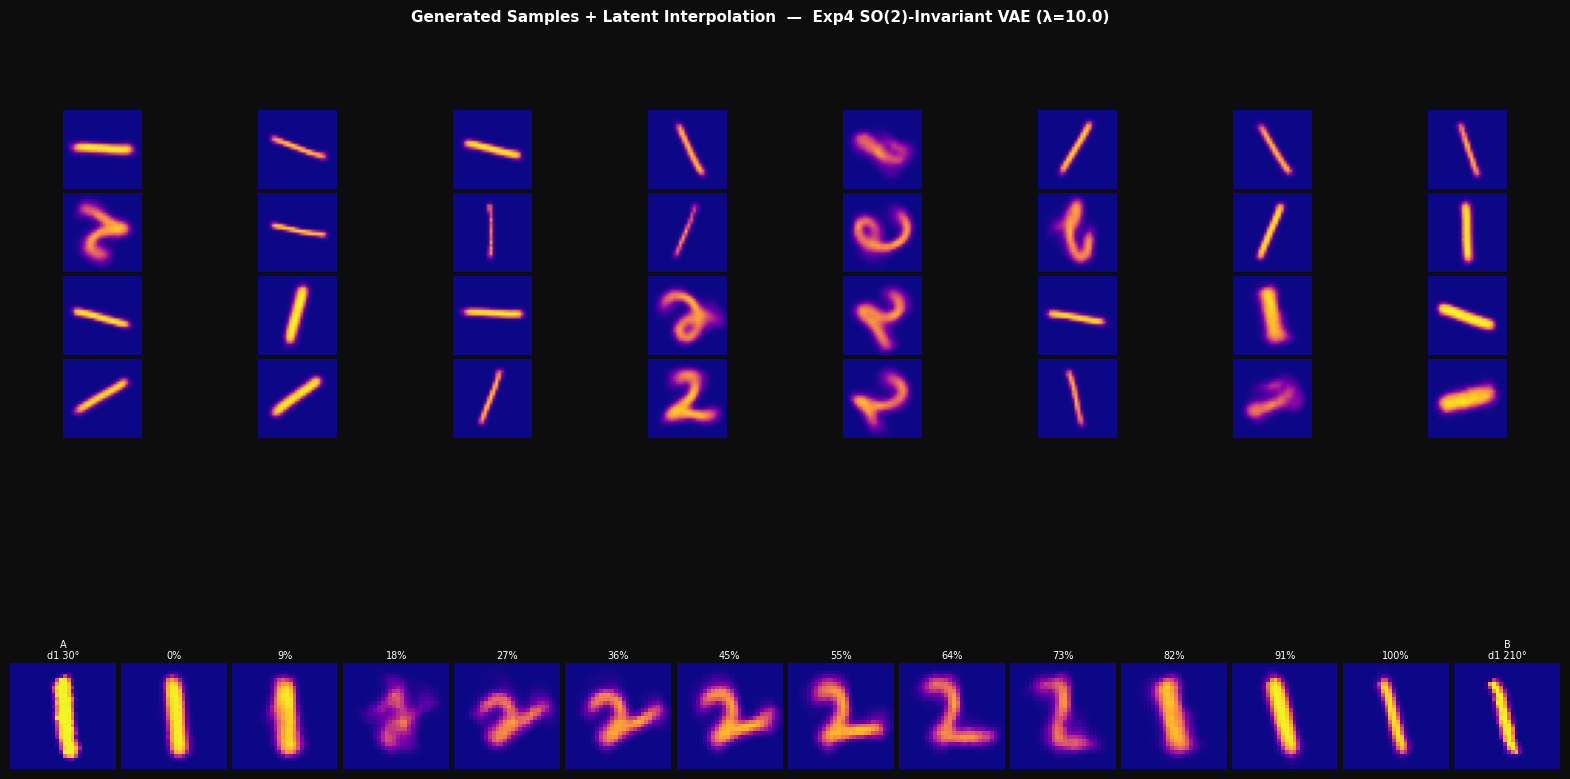

In [19]:
best_model.eval()
fig = plt.figure(figsize=(20, 10), facecolor="#0d0d0d")
fig.suptitle(f"Generated Samples + Latent Interpolation  —  {EXP_NAME}",
             color="white", fontsize=11, fontweight="bold")
gs_fig = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)
 
# generated samples
gs_top = gridspec.GridSpecFromSubplotSpec(4, 8, subplot_spec=gs_fig[0], hspace=0.05, wspace=0.05)
with torch.no_grad():
    z_rand = torch.randn(32, LATENT_DIM, device=device)
    gen    = best_model.decoder(z_rand).cpu()
for i in range(32):
    ax = fig.add_subplot(gs_top[i//8, i%8])
    ax.imshow(gen[i].squeeze().numpy(), cmap="plasma", vmin=0, vmax=1); ax.axis("off")
    if i == 0: ax.set_ylabel("z~N(0,I)\ngenerated", color="white", fontsize=8, rotation=0, labelpad=55)
 
# interpolation
N_INT = 12
ra = torch.randperm(len(test_imgs))[0]; rb = torch.randperm(len(test_imgs))[0]
ia = test_imgs[ra:ra+1].to(device);    ib = test_imgs[rb:rb+1].to(device)
with torch.no_grad():
    za, _ = best_model.encoder(ia); zb, _ = best_model.encoder(ib)
    interp = [best_model.decoder((1-a)*za + a*zb).cpu() for a in np.linspace(0,1,N_INT)]
 
la = test_lbls[ra].item(); aa = test_angs[ra].item()
lb = test_lbls[rb].item(); ab = test_angs[rb].item()
gs_bot = gridspec.GridSpecFromSubplotSpec(1, N_INT+2, subplot_spec=gs_fig[1], hspace=0.05, wspace=0.05)
all_int = [ia.cpu()] + interp + [ib.cpu()]
int_lbl = ([f"A\nd{la} {aa}°"] + [f"{a:.0%}" for a in np.linspace(0,1,N_INT)] + [f"B\nd{lb} {ab}°"])
for i, (img, lbl) in enumerate(zip(all_int, int_lbl)):
    ax = fig.add_subplot(gs_bot[0, i])
    ax.imshow(img.squeeze().numpy(), cmap="plasma", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(lbl, color="white", fontsize=7, pad=3)
    if i == 0: ax.set_ylabel("interpolation", color="white", fontsize=8, rotation=0, labelpad=52)
 
plt.savefig(os.path.join(OUT_DIR, "F_generated_interp.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [20]:
print("=" * 60)
print(f"  RESULTS  —  {EXP_NAME}")
print("=" * 60)
print()
print("  PRIMARY EVALUATION METRICS (symmetry discovery)")
print(f"    RIE  (Rotation Invariance Error)  : {rie:.4f}  ← lower = better")
print(f"    LP-AUC (Linear Probe AUC)         : {lp_auc:.4f}  ← higher = better")
print(f"    OCS  (Orbit Circularity Score)     : {ocs:.4f}  ← characterises geometry")
print()
print("  TRAINING DIAGNOSTICS (do not compare across experiments directly)")
print(f"    best val ELBO (β=1)  : {min(history.get('val_elbo', history['val_loss'])):.2f}")
print(f"    final val recon      : {history['val_recon'][-1]:.2f}")
print(f"    final val KL         : {history['val_kl'][-1]:.4f}")
print()
# verdict
if rie < 1.0 and lp_auc > 0.90:
    verdict = "✅  symmetry learned AND class information preserved"
elif rie < 1.0 and lp_auc < 0.80:
    verdict = "⚠️   rotation-invariant BUT class information lost — model may have collapsed"
elif rie > 2.0 and lp_auc > 0.90:
    verdict = "❌  class info ok BUT symmetry not learned — check lambda_inv or training"
else:
    verdict = "🔄  partial — continue training or adjust hyperparameters"
print(f"  VERDICT : {verdict}")
print()
print("=" * 60)
print(f"  outputs → {OUT_DIR}/")
for fn in sorted(os.listdir(OUT_DIR)):
    kb = os.path.getsize(os.path.join(OUT_DIR, fn)) // 1024
    print(f"    {fn:<42} {kb:>5} KB")

  RESULTS  —  Exp4 SO(2)-Invariant VAE (λ=10.0)

  PRIMARY EVALUATION METRICS (symmetry discovery)
    RIE  (Rotation Invariance Error)  : 0.8597  ← lower = better
    LP-AUC (Linear Probe AUC)         : 0.9968  ← higher = better
    OCS  (Orbit Circularity Score)     : 0.8250  ← characterises geometry

  TRAINING DIAGNOSTICS (do not compare across experiments directly)
    best val ELBO (β=1)  : 124.32
    final val recon      : 108.33
    final val KL         : 25.0194

  VERDICT : ✅  symmetry learned AND class information preserved

  outputs → /kaggle/working/exp4_equivariant_vae/
    00_data_preview.png                           35 KB
    B_epoch_snapshots.png                        245 KB
    C_reconstructions.png                         66 KB
    D_latent_traversal.png                        67 KB
    E_eval_metrics.png                           519 KB
    F_generated_interp.png                        90 KB
    best_model.pt                              12193 KB
    snap_ep001.p